In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import numpy as np
import xarray as xr

In [11]:
path = "/Users/tillweiss/Desktop/MODSNOW/pixelwise_ndvi_sca_regression_annual_full_ds2.nc"

ds = xr.open_dataset(path)

r2 = ds["r2"]#.values
#slope = ds["slope"].values
#intercept = ds["intercept"].values
#n = ds["n"].values

print(ds)

<xarray.Dataset> Size: 11MB
Dimensions:    (lat: 540, lon: 800)
Coordinates:
  * lat        (lat) float64 4kB 43.33 43.33 43.32 43.32 ... 41.1 41.09 41.09
  * lon        (lon) float64 6kB 58.17 58.17 58.18 58.18 ... 61.49 61.49 61.5
Data variables:
    slope      (lat, lon) float64 3MB ...
    intercept  (lat, lon) float64 3MB ...
    r2         (lat, lon) float64 3MB ...
    n          (lat, lon) int16 864kB ...
Attributes:
    ndvi_doy_start:       200
    ndvi_doy_end:         260
    sca_doy_start:        140
    sca_doy_end:          180
    min_n:                8
    min_tile_valid_frac:  0.7
    chosen_x0:            0
    chosen_y0:            0
    usable_fraction:      0.5020648148148148
    downsample:           2
    downsample_reduce:    mean


/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


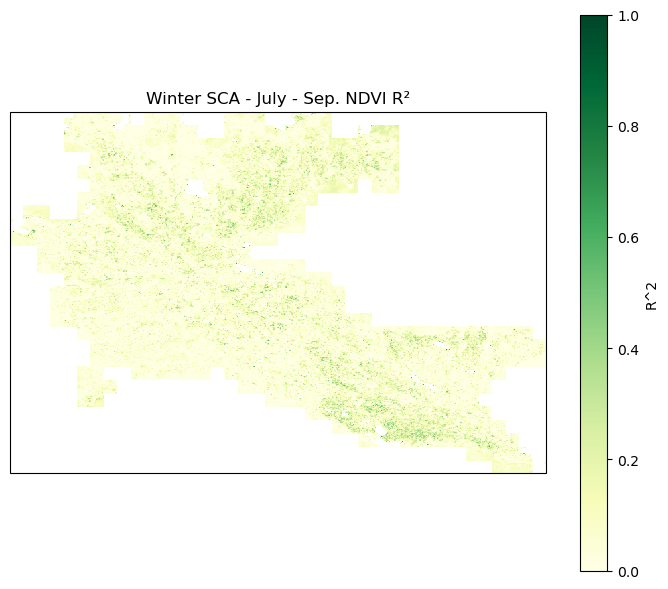

In [13]:
ndvi_map = r2#.sel(time='2025-08-13')

fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ndvi_map.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    vmin=0,
    vmax=1,
    cbar_kwargs={'label': 'R^2'}
)

ax.coastlines()
ax.set_title('Winter SCA - July - Sep. NDVI R²')
plt.tight_layout()
plt.show()

In [5]:
path = "/Users/tillweiss/Desktop/MODSNOW/pixelwise_ndvi_sca_regression_annual_full_ds2.nc"
ds = xr.open_dataset(path)

r2 = ds["r2"].to_numpy()          # <- NumPy
slope = ds["slope"].to_numpy()
intercept = ds["intercept"].to_numpy()
n = ds["n"].to_numpy()

def finite_np(a):
    a = np.asarray(a)
    return a[np.isfinite(a)]

r2_f = finite_np(r2)
slope_f = finite_np(slope)
intercept_f = finite_np(intercept)

print("Grid:", r2.shape, "pixels:", r2.size)
print("Valid r2:", np.isfinite(r2).sum(), "fraction:", np.isfinite(r2).mean())
print("R2 min/median/mean/max:", r2_f.min(), np.median(r2_f), r2_f.mean(), r2_f.max())

Grid: (540, 800) pixels: 432000
Valid r2: 216892 fraction: 0.5020648148148148
R2 min/median/mean/max: 6.955547249276606e-13 0.03880715935318341 0.06843295510361493 0.8552383576849628


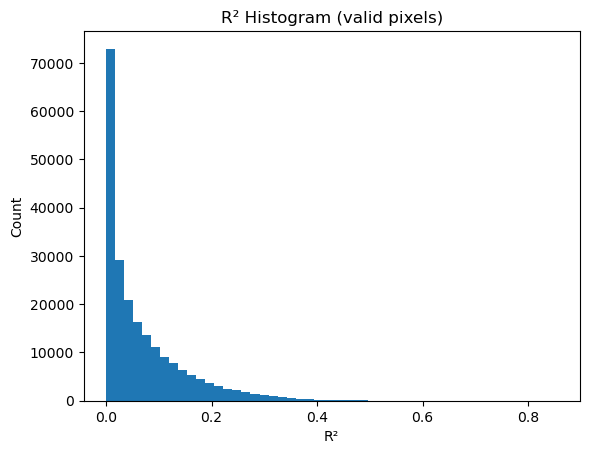

In [6]:
plt.figure()
plt.hist(r2_f, bins=50)
plt.title("R² Histogram (valid pixels)")
plt.xlabel("R²")
plt.ylabel("Count")
plt.show()

In [7]:
for thr in [0.1, 0.2, 0.3, 0.4]:
    print(f"fraction r2 > {thr}: {(r2_f > thr).mean():.3f}")

fraction r2 > 0.1: 0.250
fraction r2 > 0.2: 0.078
fraction r2 > 0.3: 0.021
fraction r2 > 0.4: 0.004


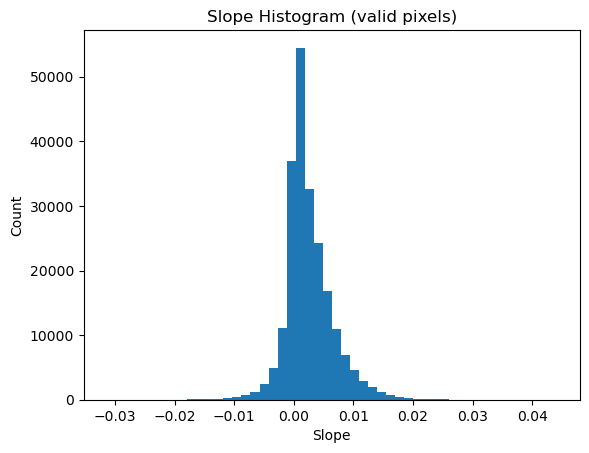

In [8]:
plt.figure()
plt.hist(slope_f, bins=50)
plt.title("Slope Histogram (valid pixels)")
plt.xlabel("Slope")
plt.ylabel("Count")
plt.show()

In [9]:
def summary(r2):
    r2f = r2[np.isfinite(r2)]
    return {
        "mean": r2f.mean(),
        "median": np.median(r2f),
        ">0.1": (r2f > 0.1).mean(),
        ">0.2": (r2f > 0.2).mean(),
        ">0.3": (r2f > 0.3).mean(),
    }

summary(r2)

{'mean': np.float64(0.06843295510361493),
 'median': np.float64(0.03880715935318341),
 '>0.1': np.float64(0.25035040480976706),
 '>0.2': np.float64(0.0780757243236265),
 '>0.3': np.float64(0.02052634490898696)}